In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
car_df=pd.read_csv("/content/CAR.csv")

In [155]:
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [156]:
car_df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [157]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [158]:
car_df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [159]:
car_df.shape

(4340, 8)

In [160]:
## for stastical analysis
car_df.describe()

,year,selling_price,km_driven
count,"4,340","4,340","4,340"
mean,"2,013","504,127","66,216"
std,4,"578,549","46,644"
min,"1,992","20,000",1
25%,"2,011","208,750","35,000"
50%,"2,014","350,000","60,000"
75%,"2,016","600,000","90,000"
max,"2,020","8,900,000","806,599"


In [161]:
car_df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner


In [162]:
car_df.sample()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
2093,Hyundai i10 Sportz 1.2 AT,2015,500000,50000,Petrol,Dealer,Automatic,First Owner


In [163]:
# Check for duplicate rows
car_df.duplicated().sum()

np.int64(763)

In [164]:
# Remove 763 duplicate rows
car_df = car_df.drop_duplicates()

In [165]:
car_df.duplicated().sum()

np.int64(0)

In [166]:
car_df.shape

(3577, 8)

In [167]:
##univariate
car_df['name'].nunique()
## this dataset has unique 1491 car models

1491

In [168]:
car_df['name']

,name
0,Maruti 800 AC
1,Maruti Wagon R LXI Minor
2,Hyundai Verna 1.6 SX
3,Datsun RediGO T Option
4,Honda Amaze VX i-DTEC
...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel)
4336,Hyundai i20 Magna 1.4 CRDi
4337,Maruti 800 AC BSIII
4338,Hyundai Creta 1.6 CRDi SX Option


In [169]:
data='Maruti 800 AC'
func=lambda x:x.split(' ')[0]
func(data)

'Maruti'

In [170]:
car_df['name'].apply(lambda x:x.split(' ')[0])

,name
0,Maruti
1,Maruti
2,Hyundai
3,Datsun
4,Honda
...,...
4335,Hyundai
4336,Hyundai
4337,Maruti
4338,Hyundai


In [171]:
car_df['Brand Name']=car_df['name'].apply(lambda x:x.split(' ')[0])

In [172]:
car_df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda
...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner,Maruti
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner,Hyundai


In [173]:
## this data set has unique brand name
car_df['Brand Name'].nunique()

29

In [174]:
## this data set has no of brand cars means maruti has 1280 car
car_df['Brand Name'].value_counts()

,count
Brand Name,
Maruti,1072
Hyundai,637
Mahindra,328
Tata,308
Ford,220
Honda,216
Toyota,170
Chevrolet,151
Renault,110


In [175]:
car_df['Brand Name'].value_counts().tail()

,count
Brand Name,
MG,2
Force,1
Daewoo,1
Isuzu,1
Kia,1


In [176]:
car_df['Brand Name'].value_counts().head()

,count
Brand Name,
Maruti,1072
Hyundai,637
Mahindra,328
Tata,308
Ford,220


<Axes: xlabel='Brand Name'>

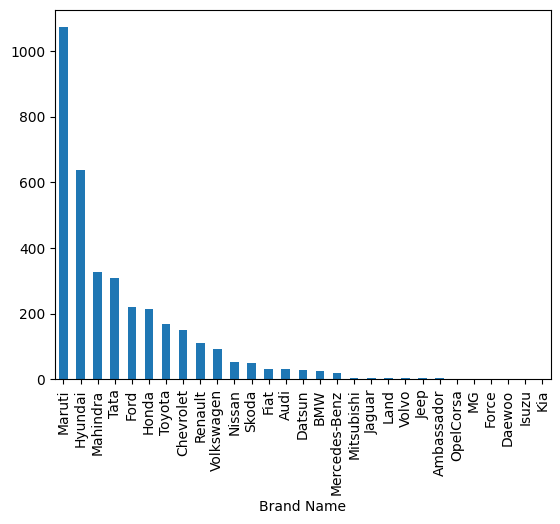

In [177]:
## using bar plot compare the brand name
car_df['Brand Name'].value_counts().plot(kind='bar')

<Axes: xlabel='Brand Name'>

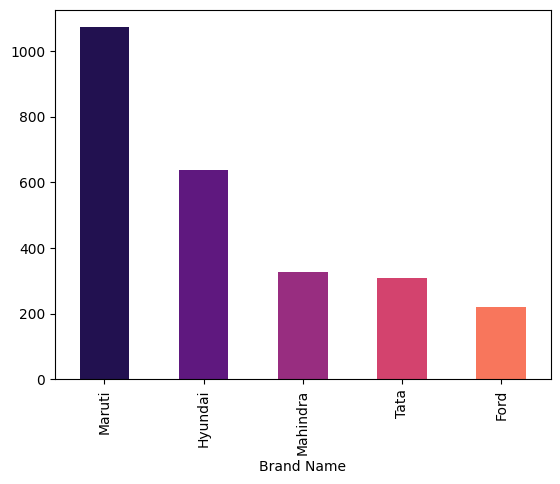

In [178]:
## seaborn for data visualization with different colors to show brand name
car_df['Brand Name'].value_counts().head().plot(kind='bar',color=sns.color_palette('magma'))

<Axes: xlabel='Brand Name'>

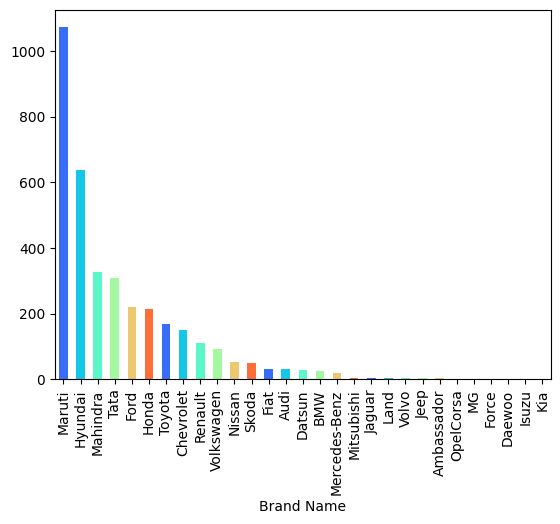

In [179]:
car_df['Brand Name'].value_counts().plot(kind='bar',color=sns.color_palette('rainbow'))

<Axes: xlabel='year'>

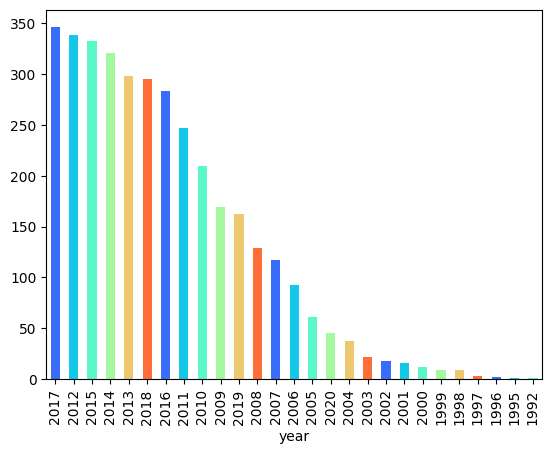

In [180]:
## har year ka record/sales
car_df['year'].value_counts().plot(kind='bar',color=sns.color_palette('rainbow'))

<Axes: xlabel='year'>

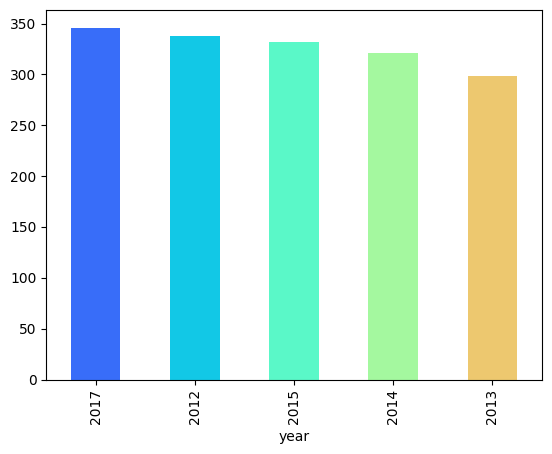

In [181]:
car_df['year'].value_counts().head().plot(kind='bar',color=sns.color_palette('rainbow'))

<Axes: xlabel='year'>

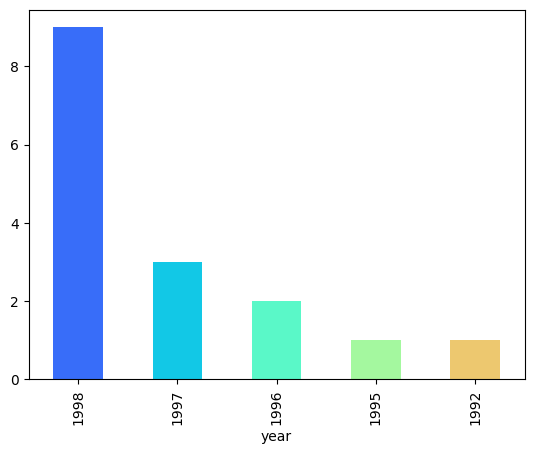

In [182]:
car_df['year'].value_counts().tail().plot(kind='bar',color=sns.color_palette('rainbow'))

In [183]:
## agar koi bhi columns ke index ko chaiye uske liye bar bar upar na jana pade to hma bich me columns ko run kr lete h
car_df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'Brand Name'],
      dtype='object')

<Axes: xlabel='selling_price'>

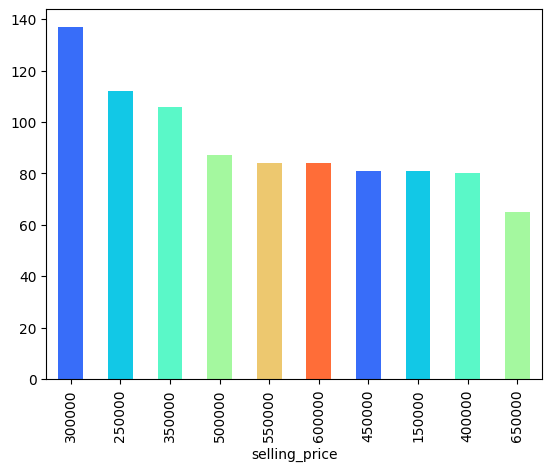

In [184]:
##  itne amount ki sabse jyada cars present h
car_df['selling_price'].value_counts().head(10).plot(kind='bar',color=sns.color_palette('rainbow'))

In [185]:
## price k according top 10
car_df['selling_price'].sort_values(ascending=False).head(10)

,selling_price
3872,8900000
89,8150000
3969,5500000
555,4950000
3883,4800000
3453,4800000
963,4700000
101,4500000
4047,4500000
539,4400000


In [186]:
## price k according bottom 10
car_df['selling_price'].sort_values(ascending=False).tail(10)

,selling_price
2730,40000
137,40000
3215,40000
4290,37500
1832,35000
2849,35000
3206,35000
2444,30000
2495,22000
2662,20000


<Axes: >

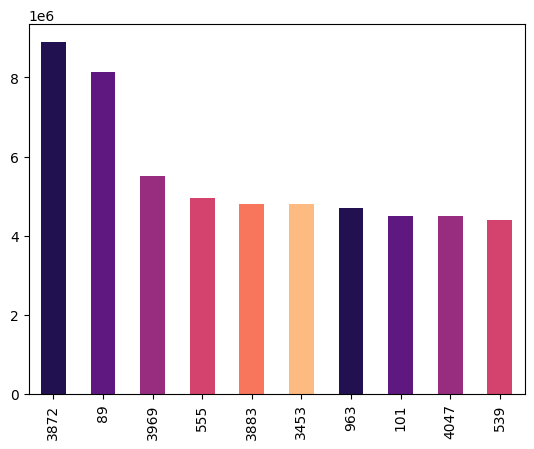

In [187]:
## bar plot price k according top 10
car_df['selling_price'].sort_values(ascending=False).head(10).plot(kind='bar',color=sns.color_palette('magma'))

<Axes: >

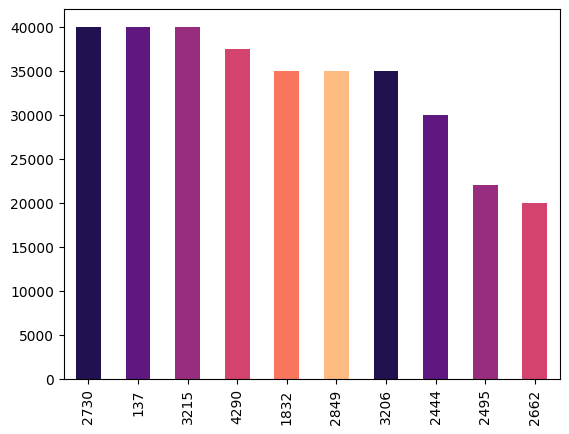

In [188]:
## bar plot price k according botto, 10
car_df['selling_price'].sort_values(ascending=False).tail(10).plot(kind='bar',color=sns.color_palette('magma'))

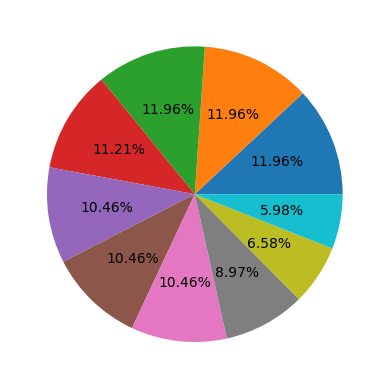

In [189]:
## low price range ka pie chart
data=car_df['selling_price'].sort_values(ascending=False).tail(10).to_numpy()
plt.pie(data,autopct='%.2f%%')
plt.show()

In [190]:
data


array([40000, 40000, 40000, 37500, 35000, 35000, 35000, 30000, 22000,
       20000])

In [191]:
## fuel, seller_type,transmission, owner, Brand Name,

<Axes: xlabel='fuel'>

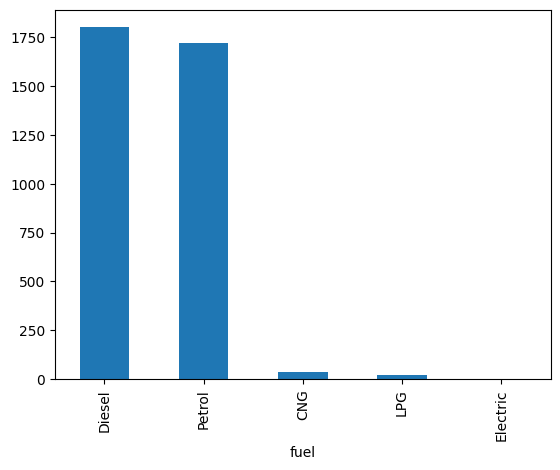

In [192]:
car_df['fuel'].value_counts().plot(kind='bar')

<Axes: xlabel='seller_type'>

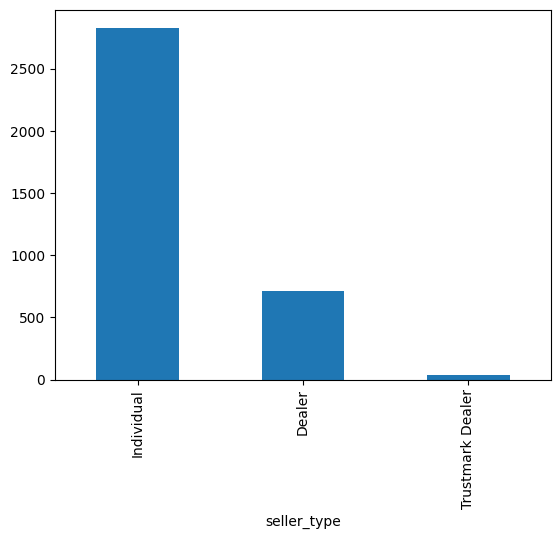

In [193]:
car_df['seller_type'].value_counts().plot(kind='bar')

<Axes: xlabel='transmission'>

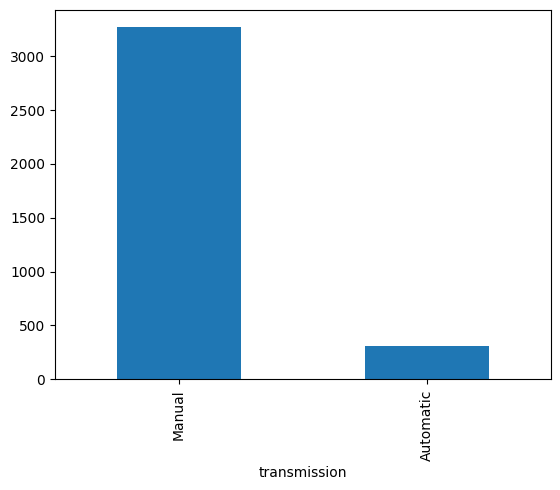

In [194]:
car_df['transmission'].value_counts().plot(kind='bar')

In [195]:
car_df['transmission'].value_counts()

,count
transmission,
Manual,3265
Automatic,312


In [196]:
car_df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda
...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner,Maruti
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner,Hyundai


<Axes: xlabel='owner'>

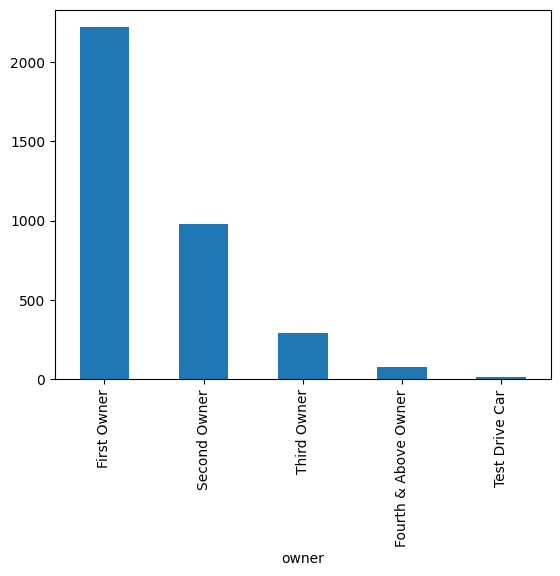

In [197]:
car_df['owner'].value_counts().plot(kind='bar')

In [198]:
car_df['selling_price'].min()

20000

In [199]:
car_df['selling_price'].max()

8900000

In [200]:
car_df[car_df['selling_price']==car_df['selling_price'].min()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
2662,Ford Ikon 1.6 ZXI NXt,2005,20000,25000,Petrol,Individual,Manual,Second Owner,Ford


In [201]:
car_df[car_df['selling_price']==car_df['selling_price'].max()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
3872,Audi RS7 2015-2019 Sportback Performance,2016,8900000,13000,Petrol,Dealer,Automatic,First Owner,Audi


<Axes: xlabel='year', ylabel='selling_price'>

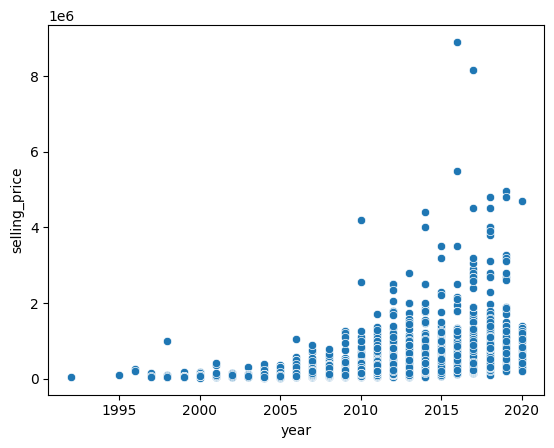

In [202]:
sns.scatterplot(data=car_df, x='year', y='selling_price')

<Axes: xlabel='year', ylabel='selling_price'>

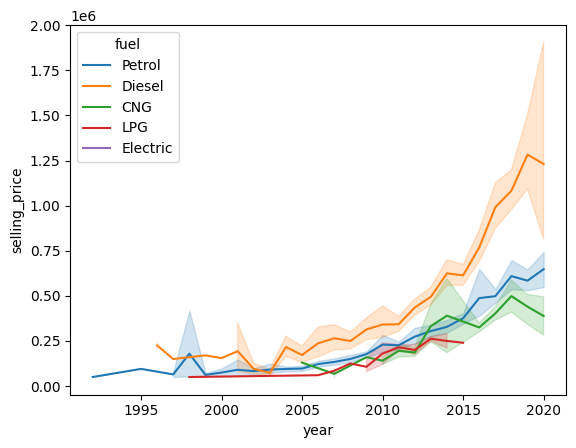

In [203]:
sns.lineplot(
    data=car_df,
    x='year',
    y='selling_price',
    hue='fuel'
)

In [204]:
## Bivariat

In [205]:
car_df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda
...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner,Hyundai
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner,Maruti
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner,Hyundai


In [206]:
## groupby --> same category wali rows ko combine kr deta h textual p group(fuel,auto,owner) ,  numerical p aggrate(price, year)

In [207]:
grouped_df=car_df.groupby('fuel')

In [208]:
pd.DataFrame(list( grouped_df)[0])

,0
0,CNG
1,name ...


In [209]:
grouped_df.first()

,name,year,selling_price,km_driven,seller_type,transmission,owner,Brand Name
fuel,,,,,,,,
CNG,Maruti Celerio Green VXI,2017,365000,78000,Individual,Manual,First Owner,Maruti
Diesel,Hyundai Verna 1.6 SX,2012,600000,100000,Individual,Manual,First Owner,Hyundai
Electric,Toyota Camry Hybrid,2006,310000,62000,Dealer,Automatic,Second Owner,Toyota
LPG,Maruti Wagon R DUO LPG,2014,210000,90000,Individual,Manual,First Owner,Maruti
Petrol,Maruti 800 AC,2007,60000,70000,Individual,Manual,First Owner,Maruti


In [210]:
grouped_df.get_group('CNG')

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner,Maruti
176,Maruti Alto K10 LXI CNG,2020,282000,40000,CNG,Individual,Manual,First Owner,Maruti
351,Tata Indigo CS Emax CNG GLX,2014,185000,72000,CNG,Dealer,Manual,First Owner,Tata
352,Maruti Eeco 5 STR With AC Plus HTR CNG,2012,229999,75000,CNG,Dealer,Manual,First Owner,Maruti
361,Hyundai Santro Xing GLS CNG,2010,130000,98000,CNG,Individual,Manual,Second Owner,Hyundai
664,Hyundai Santro Xing GL PLUS CNG,2007,90000,80000,CNG,Individual,Manual,Third Owner,Hyundai
712,Maruti Ertiga VXI CNG,2013,525000,56228,CNG,Dealer,Manual,First Owner,Maruti
824,Maruti Alto 800 CNG LXI,2012,170000,97000,CNG,Individual,Manual,Second Owner,Maruti
863,Hyundai Accent GLE CNG,2009,160000,70000,CNG,Individual,Manual,Third Owner,Hyundai
1138,Maruti Wagon R LXI CNG,2013,250000,71000,CNG,Individual,Manual,Second Owner,Maruti


In [211]:
grouped_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner,Maruti
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner,Hyundai
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner,Maruti
27,Hyundai Venue SX Opt Diesel,2019,1195000,5000,Diesel,Dealer,Manual,First Owner,Hyundai
28,Chevrolet Enjoy TCDi LTZ 7 Seater,2013,390000,33000,Diesel,Individual,Manual,Second Owner,Chevrolet


In [212]:
grouped_df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
3341,Chevrolet Beat LT LPG,2011,200000,110000,LPG,Individual,Manual,First Owner,Chevrolet
3394,Hyundai EON LPG Magna Plus,2012,170000,170000,LPG,Individual,Manual,Third Owner,Hyundai
3407,Maruti Wagon R Duo Lxi,2010,120000,90000,LPG,Individual,Manual,Second Owner,Maruti
3752,Hyundai EON LPG Magna Plus,2015,240000,110000,LPG,Individual,Manual,First Owner,Hyundai
3781,Maruti Wagon R LXI DUO BSIII,2007,70000,162000,LPG,Individual,Manual,First Owner,Maruti
3835,Maruti Zen Estilo LXI Green (CNG),2010,110000,80000,CNG,Individual,Manual,Fourth & Above Owner,Maruti
4063,Maruti Eeco 5 STR With AC Plus HTR CNG,2017,440000,14100,CNG,Dealer,Manual,First Owner,Maruti
4076,Maruti Ertiga VXI CNG,2014,595000,56600,CNG,Dealer,Manual,First Owner,Maruti
4140,Maruti Eeco 5 STR With AC Plus HTR CNG,2018,409999,45000,CNG,Individual,Manual,First Owner,Maruti
4145,Toyota Camry Hybrid,2006,310000,62000,Electric,Dealer,Automatic,Second Owner,Toyota


In [213]:
## cng me 4k km chali min disel me 1 km and so on
grouped_df['km_driven'].min()

,km_driven
fuel,
CNG,4000
Diesel,1
Electric,62000
LPG,29000
Petrol,101


In [214]:
grouped_df['km_driven'].max()

,km_driven
fuel,
CNG,120000
Diesel,560000
Electric,62000
LPG,170000
Petrol,806599


In [215]:
grouped_df['km_driven'].max().sort_values()

,km_driven
fuel,
Electric,62000
CNG,120000
LPG,170000
Diesel,560000
Petrol,806599


<Axes: xlabel='fuel'>

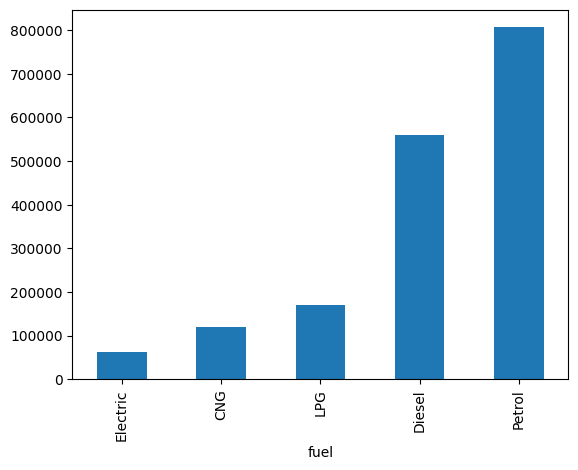

In [216]:
grouped_df['km_driven'].max().sort_values().plot(kind='bar')

In [217]:
grouped_df['year'].min().sort_values()

,year
fuel,
Petrol,1992
Diesel,1996
LPG,1998
CNG,2005
Electric,2006


In [218]:
grouped_df['year'].max().sort_values()

,year
fuel,
Electric,2006
LPG,2015
Diesel,2020
CNG,2020
Petrol,2020


In [219]:
car_df.sample()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
2905,Mahindra Bolero Power Plus SLX,2018,900000,25000,Diesel,Individual,Manual,First Owner,Mahindra


In [220]:
brand_grouped_df=car_df.groupby('Brand Name')

In [221]:
brand_grouped_df['selling_price'].min()

,selling_price
Brand Name,
Ambassador,50000
Audi,650000
BMW,480000
Chevrolet,50000
Daewoo,60000
Datsun,200000
Fiat,55000
Force,346000
Ford,20000


In [222]:
brand_grouped_df['selling_price'].max()

,selling_price
Brand Name,
Ambassador,430000
Audi,8900000
BMW,4950000
Chevrolet,1000000
Daewoo,60000
Datsun,450000
Fiat,890000
Force,346000
Ford,3200000


<Axes: xlabel='Brand Name'>

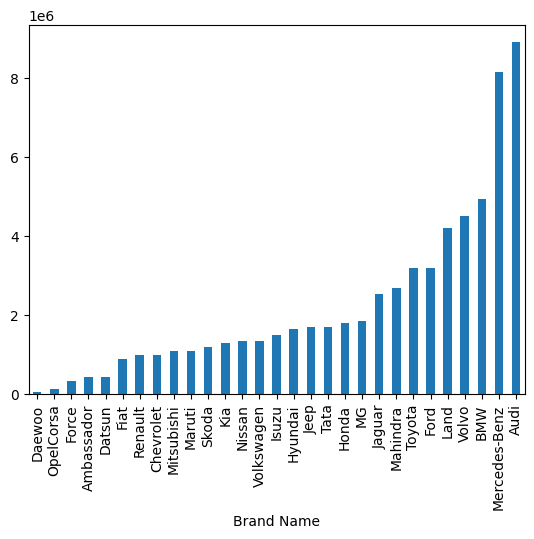

In [223]:
brand_grouped_df['selling_price'].max().sort_values().plot(kind='bar')

In [224]:
car_df.sample()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Brand Name
1462,Audi A8 L 3.0 TDI quattro,2009,1250000,47000,Diesel,Dealer,Automatic,Second Owner,Audi


In [225]:
pd.options.display.float_format='{:,.0f}'.format
## float to integer conversions

In [226]:
brand_grouped_df['selling_price'].mean()

,selling_price
Brand Name,
Ambassador,"200,000"
Audi,"2,185,452"
BMW,"2,242,800"
Chevrolet,"232,713"
Daewoo,"60,000"
Datsun,"296,552"
Fiat,"287,094"
Force,"346,000"
Ford,"563,627"


In [227]:
car_df[car_df['Brand Name']=='Audi']['selling_price'].describe()

,selling_price
count,31
mean,"2,185,452"
std,"1,590,988"
min,"650,000"
25%,"1,250,000"
50%,"1,580,000"
75%,"2,750,000"
max,"8,900,000"


In [228]:
grouped_ob=car_df.groupby(['Brand Name','fuel'])

In [229]:
grouped_ob['selling_price'].min()

Brand Name     fuel    
Ambassador     Diesel        50000
               Petrol       430000
Audi           Diesel       850000
               Petrol       650000
BMW            Diesel       700000
               Petrol       480000
Chevrolet      CNG          229999
               Diesel        95000
               LPG          200000
               Petrol        50000
Daewoo         Petrol        60000
Datsun         Petrol       200000
Fiat           Diesel        55000
               Petrol        80000
Force          Diesel       346000
Ford           Diesel        80000
               Petrol        20000
Honda          Diesel       290000
               Petrol        65000
Hyundai        CNG           90000
               Diesel        85000
               LPG          170000
               Petrol        48000
Isuzu          Diesel      1500000
Jaguar         Diesel      1800000
               Petrol      2050000
Jeep           Diesel      1490000
               Petrol      1400000
Kia            Diesel      1300000
Land           Diesel      2349000
               Petrol      4000000
MG             Diesel      1825000
               Petrol      1860000
Mahindra       Diesel        80000
               Petrol        80000
Maruti         CNG           45000
               Diesel        75000
               LPG           50000
               Petrol        30000
Mercedes-Benz  Diesel       350000
               Petrol       850000
Mitsubishi     Diesel       750000
               Petrol       525000
Nissan         Diesel       138000
               Petrol       164000
OpelCorsa      Petrol        35000
Renault        Diesel       300000
               Petrol       200000
Skoda          Diesel        90000
               Petrol       269000
Tata           CNG          185000
               Diesel        45000
               Petrol        35000
Toyota         Diesel       150000
               Electric     310000
               Petrol        95000
Volkswagen     Diesel       130000
               Petrol       211000
Volvo          Diesel      1750000
Name: selling_price, dtype: int64

In [230]:
## multivariat analysis

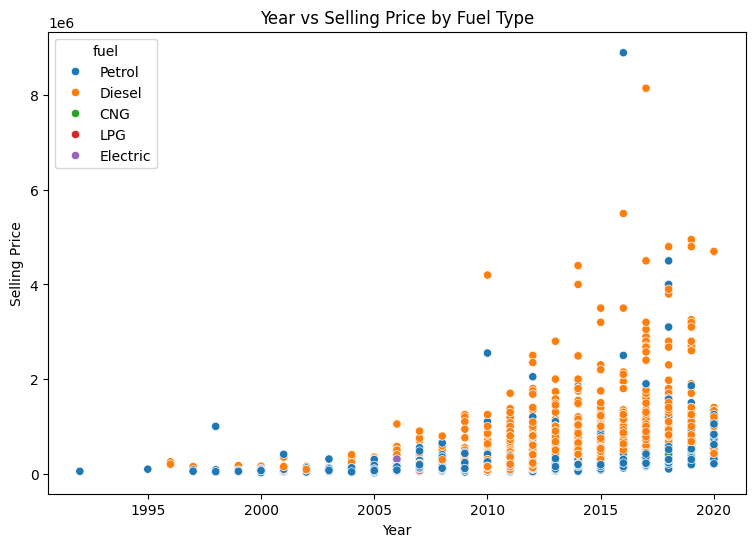

In [231]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=car_df, x='year', y='selling_price',hue='fuel')
plt.title('Year vs Selling Price by Fuel Type')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

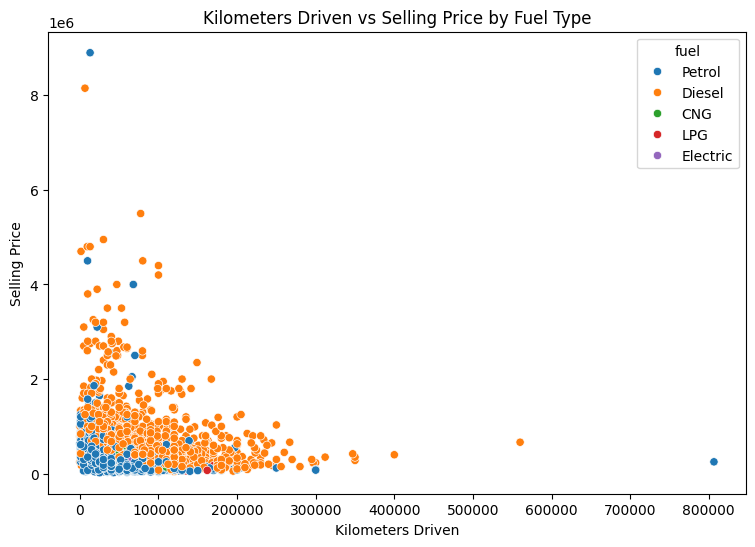

In [232]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=car_df, x='km_driven',y='selling_price', hue='fuel')
plt.title('Kilometers Driven vs Selling Price by Fuel Type')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.show()

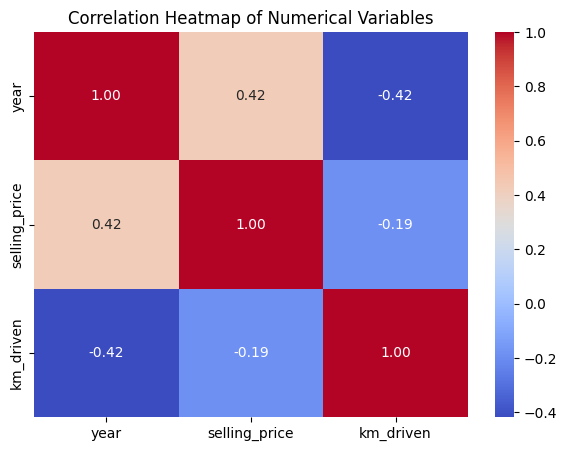

In [233]:
correlation = car_df[['year', 'selling_price', 'km_driven']].corr()
plt.figure(figsize=(7,5))
sns.heatmap(correlation, annot=True,cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [234]:
## Important Observations and Insights

#- The dataset contains 4340 car records and 8 columns.
# - No missing values are present in the dataset.
# - No duplicate records were found.
# - Maruti has the highest number of cars in the dataset.
# - Most cars have manual transmission.
# - Selling price varies considerably across different brands.
# - Newer cars generally have higher selling prices.
#- Cars with higher kilometers driven generally tend to have lower selling prices.
# -Some very high-priced cars appear as outliers.